<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/01_foundations/probability_statistics/experiment_bias_variance_tradeoff_polynomial_regression_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

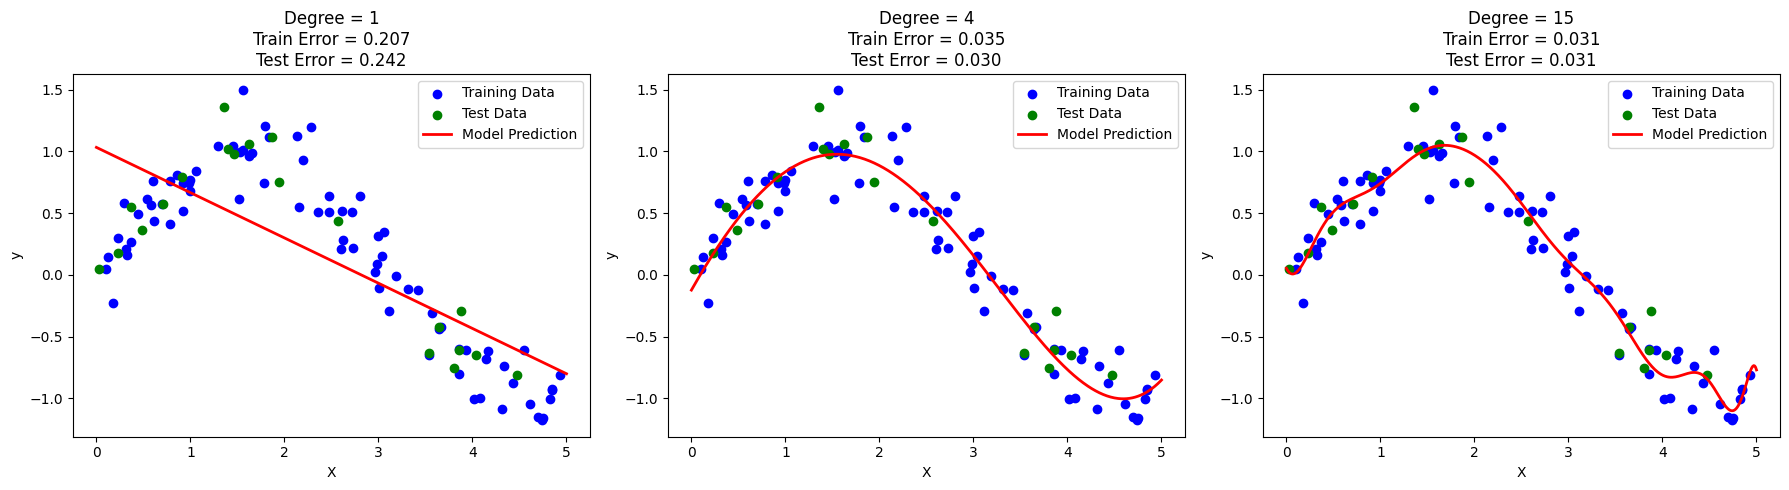


INTERPRETATION:
--------------------------------------------------
Degree 1  -> High Bias (Underfitting)
Degree 4  -> Balanced Model
Degree 15 -> High Variance (Overfitting)
--------------------------------------------------


In [1]:
# ============================================================
# BIAS-VARIANCE TRADEOFF DEMO
# ============================================================

# STEP 1 — Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ============================================================
# STEP 2 — Create Synthetic Dataset
# ============================================================

np.random.seed(42)

X = np.sort(5 * np.random.rand(100, 1), axis=0)

# True function
y_true = np.sin(X).ravel()

# Add noise
y = y_true + np.random.normal(0, 0.2, size=100)

# ============================================================
# STEP 3 — Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 4 — Create Different Complexity Models
# ============================================================

degrees = [1, 4, 15]

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):

    # Polynomial Regression Pipeline
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Errors
    train_error = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_error = mean_squared_error(
        y_test,
        y_test_pred
    )

    # Smooth curve for visualization
    X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    # ========================================================
    # Plotting
    # ========================================================

    plt.subplot(1, 3, i + 1)

    plt.scatter(
        X_train,
        y_train,
        color='blue',
        label='Training Data'
    )

    plt.scatter(
        X_test,
        y_test,
        color='green',
        label='Test Data'
    )

    plt.plot(
        X_plot,
        y_plot,
        color='red',
        linewidth=2,
        label='Model Prediction'
    )

    plt.title(
        f"Degree = {degree}\n"
        f"Train Error = {train_error:.3f}\n"
        f"Test Error = {test_error:.3f}"
    )

    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 5 — Understanding the Output
# ============================================================

print("\nINTERPRETATION:")
print("--------------------------------------------------")
print("Degree 1  -> High Bias (Underfitting)")
print("Degree 4  -> Balanced Model")
print("Degree 15 -> High Variance (Overfitting)")
print("--------------------------------------------------")